In [2]:
# Install sentence-transformers and a CPU-only torch wheel (helps avoid CUDA DLL issues on Windows)
# This magic will be no-op if packages are already installed.
%pip install -q sentence-transformers torch --extra-index-url https://download.pytorch.org/whl/cpu

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# HTML Parsing
from bs4 import BeautifulSoup
import requests
from time import sleep

# NLP and Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
import textstat
from sklearn.feature_extraction.text import TfidfVectorizer
# sentence_transformers import is handled below with a safe fallback

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Persistence
import joblib
import json
from pathlib import Path

# Try to import SentenceTransformer; provide a lightweight fallback if import or DLL init fails
try:
    from sentence_transformers import SentenceTransformer
    EMBEDDING_BACKEND = 'sbert'
except Exception as e:
    # If import fails (ModuleNotFoundError or OSError), create a small fallback that uses TF-IDF vectors.
    # This keeps the rest of the pipeline functional without requiring heavy torch/CUDA binaries.
    print(f"Warning: sentence-transformers unavailable ({str(e)[:200]}). Using TF-IDF fallback for embeddings.")
    class SentenceTransformer:
        """
        Minimal fallback that mimics SentenceTransformer.encode(texts) using TF-IDF vectors.
        Produces fixed-size vectors (384 dims) by truncating/padding TF-IDF features.
        """
        def __init__(self, model_name=None, max_features=384):
            self.model_name = model_name
            self.max_features = max_features
            self._vectorizer = None

        def encode(self, texts, show_progress_bar=False):
            # Fit vectorizer on provided texts if not already fitted
            if self._vectorizer is None:
                self._vectorizer = TfidfVectorizer(max_features=self.max_features, stop_words='english')
                # Fit on the incoming texts to build vocabulary; safe because fallback only used when SBERT isn't available
                self._vectorizer.fit(texts)
            X = self._vectorizer.transform(texts).toarray().astype(float)
            # Ensure fixed dimensionality
            if X.shape[1] < self.max_features:
                pad = np.zeros((X.shape[0], self.max_features - X.shape[1]), dtype=float)
                X = np.hstack([X, pad])
            elif X.shape[1] > self.max_features:
                X = X[:, :self.max_features]
            return X

    EMBEDDING_BACKEND = 'tfidf_fallback'

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    pass

print("✓ All libraries imported successfully!")
print(f"Working directory: {Path.cwd()}")
print(f"Embedding backend: {EMBEDDING_BACKEND}")


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported successfully!
Working directory: d:\LeadWalnut\seo-content-detector\notebooks
Embedding backend: tfidf_fallback


In [4]:
# ============================================================================
# CELL 2: Configuration and Helper Functions
# ============================================================================

# Configuration
DATA_DIR = Path('../data')
MODELS_DIR = Path('../models')

# Create directories if they don't exist
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Parameters
SIMILARITY_THRESHOLD = 0.80  # Threshold for duplicate detection
THIN_CONTENT_THRESHOLD = 500  # Word count threshold
RANDOM_STATE = 42

print("✓ Configuration set!")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

✓ Configuration set!
Data directory: ..\data
Models directory: ..\models


In [5]:
# ============================================================================
# CELL 3: Load Dataset
# ============================================================================

# Load the dataset
dataset_path = DATA_DIR / 'data.csv'

try:
    df_raw = pd.read_csv(dataset_path)
    print(f"✓ Dataset loaded successfully!")
    print(f"Shape: {df_raw.shape}")
    print(f"\nColumns: {df_raw.columns.tolist()}")
    print(f"\nFirst few rows:")
    display(df_raw.head(3))
except FileNotFoundError:
    print(f"❌ Dataset not found at {dataset_path}")
    print("Please place 'data.csv' in the data/ folder")
    raise

# Check if HTML content is available
has_html_content = 'html_content' in df_raw.columns
print(f"\nHTML content available: {has_html_content}")

✓ Dataset loaded successfully!
Shape: (81, 2)

Columns: ['url', 'html_content']

First few rows:


,url,html_content
0,https://www.cm-alliance.com/cybersecurity-blog,"<!doctype html><!--[if lt IE 7]> <html class=""..."
1,https://www.varonis.com/blog/cybersecurity-tips,"<!doctype html><html lang=""en""><head>\n <me..."
2,https://www.cisecurity.org/insights/blog/11-cy...,<!DOCTYPE html><html data-unhead-vue-server-re...



HTML content available: True


In [6]:
# ============================================================================
# CELL 4: HTML Parsing and Content Extraction
# ============================================================================

def parse_html_content(html_content):
    """
    Parse HTML content and extract meaningful text.
    
    Args:
        html_content: Raw HTML string
        
    Returns:
        dict: Extracted information (title, body_text, word_count)
    """
    try:
        soup = BeautifulSoup(html_content, 'lxml')
        
        # Extract title
        title_tag = soup.find('title')
        title = title_tag.get_text(strip=True) if title_tag else ""
        
        # Extract main content from various tags
        content_tags = ['article', 'main', 'div', 'section']
        body_text = ""
        
        for tag in content_tags:
            elements = soup.find_all(tag)
            if elements:
                for elem in elements:
                    # Get all paragraph texts
                    paragraphs = elem.find_all('p')
                    if paragraphs:
                        body_text += " ".join([p.get_text(strip=True) for p in paragraphs])
                if body_text:
                    break
        
        # Fallback: extract all paragraph tags
        if not body_text:
            paragraphs = soup.find_all('p')
            body_text = " ".join([p.get_text(strip=True) for p in paragraphs])
        
        # Clean text
        body_text = " ".join(body_text.split())
        
        # Calculate word count
        word_count = len(body_text.split())
        
        return {
            'title': title,
            'body_text': body_text,
            'word_count': word_count
        }
        
    except Exception as e:
        print(f"Error parsing HTML: {str(e)[:100]}")
        return {
            'title': "",
            'body_text': "",
            'word_count': 0
        }

def scrape_url(url, timeout=10):
    """
    Scrape HTML content from a URL.
    
    Args:
        url: URL to scrape
        timeout: Request timeout in seconds
        
    Returns:
        str: HTML content or empty string on failure
    """
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        response = requests.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()
        return response.text
    except Exception as e:
        print(f"Error scraping {url}: {str(e)[:100]}")
        return ""

# Parse HTML content or scrape URLs
print("Parsing HTML content...")
extracted_data = []

for idx, row in df_raw.iterrows():
    url = row['url']
    
    if has_html_content and pd.notna(row.get('html_content')):
        # Parse existing HTML content
        html_content = row['html_content']
        parsed = parse_html_content(html_content)
    else:
        # Scrape URL if no HTML content available
        print(f"Scraping {idx+1}/{len(df_raw)}: {url[:50]}...")
        html_content = scrape_url(url)
        if html_content:
            parsed = parse_html_content(html_content)
        else:
            parsed = {'title': "", 'body_text': "", 'word_count': 0}
        sleep(1.5)  # Rate limiting
    
    extracted_data.append({
        'url': url,
        'title': parsed['title'],
        'body_text': parsed['body_text'],
        'word_count': parsed['word_count']
    })
    
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{len(df_raw)} pages")

# Create DataFrame
df_extracted = pd.DataFrame(extracted_data)

# Filter out pages with no content
df_extracted = df_extracted[df_extracted['word_count'] > 0].reset_index(drop=True)

print(f"\n✓ Extraction complete!")
print(f"Pages with content: {len(df_extracted)}/{len(df_raw)}")
print(f"Average word count: {df_extracted['word_count'].mean():.0f}")

# Save extracted content
output_path = DATA_DIR / 'extracted_content.csv'
df_extracted.to_csv(output_path, index=False)
print(f"✓ Saved to {output_path}")

display(df_extracted.head())

Parsing HTML content...
Scraping 5/81: https://www.qnbtrust.bank/Resources/Learning-Cente...
Error scraping https://www.qnbtrust.bank/Resources/Learning-Center/Blog/7-cyber-security-tips: 403 Client Error: Forbidden for url: https://www.qnbtrust.bank/Resources/Learning-Center/Blog/7-cybe
Processed 10/81 pages
Scraping 13/81: https://www.connectwise.com/blog/phishing-preventi...
Scraping 19/81: https://www.hpe.com/us/en/what-is/sd-wan.html...
Processed 20/81 pages
Scraping 21/81: https://support.microsoft.com/en-us/windows/how-to...
Scraping 24/81: https://www.cloudflare.com/learning/access-managem...
Error scraping https://www.cloudflare.com/learning/access-management/what-is-ztna/: 403 Client Error: Forbidden for url: https://www.cloudflare.com/learning/access-management/what-is-z
Processed 30/81 pages
Processed 40/81 pages
Scraping 41/81: https://towardsdatascience.com/machine-learning-ba...
Error scraping https://towardsdatascience.com/machine-learning-basics-with-examples-part-1-c2

,url,title,body_text,word_count
0,https://www.cm-alliance.com/cybersecurity-blog,Cyber Security Blog,Cyber Crisis Tabletop Exercise Cyber Security ...,4957
1,https://www.varonis.com/blog/cybersecurity-tips,Top 10 Cybersecurity Awareness Tips: How to St...,Cybersecurity is gaining more importance globa...,1545
2,https://www.cisecurity.org/insights/blog/11-cy...,11 Cyber Defense Tips to Stay Secure at Work a...,Cybersecurity is inextricably tied to the tech...,941
3,https://www.cisa.gov/topics/cybersecurity-best...,Cybersecurity Best Practices | Cybersecurity a...,Cyberspace is particularly difficult to secure...,487
4,https://nordlayer.com/learn/network-security/b...,Network Security 101: Understanding the Basics,"Every week, networks seem to grow in size and ...",1049


In [ ]:
# ============================================================================
# CELL 5: Text Preprocessing and Feature Engineering (UPDATED)
# ============================================================================

def clean_text(text):
    """Clean and normalize text."""
    if not isinstance(text, str):
        return ""
    # Lowercase and remove extra whitespace
    text = text.lower()
    text = " ".join(text.split())
    return text

def calculate_sentence_count(text):
    """Calculate number of sentences in text."""
    try:
        sentences = sent_tokenize(text)
        return len(sentences)
    except:
        return 0

def calculate_readability(text):
    """Calculate Flesch Reading Ease score."""
    try:
        score = textstat.flesch_reading_ease(text)
        return round(score, 2)
    except:
        return 0.0

def calculate_avg_word_length(text):
    """Calculate average word length - NEW FUNCTION"""
    try:
        words = word_tokenize(str(text))
        words = [w for w in words if w.isalpha()]
        if len(words) == 0:
            return 5.0  # Default
        return round(sum(len(word) for word in words) / len(words), 2)
    except:
        words = str(text).split()
        words = [w for w in words if w.isalpha()]
        if len(words) == 0:
            return 5.0
        return round(sum(len(word) for word in words) / len(words), 2)

def extract_top_keywords(texts, top_n=5):
    """
    Extract top keywords using TF-IDF.
    
    Args:
        texts: List of text documents
        top_n: Number of top keywords to extract
        
    Returns:
        list: List of top keywords for each document
    """
    try:
        # Remove stop words
        stop_words = list(stopwords.words('english'))
        
        vectorizer = TfidfVectorizer(
            max_features=100,
            stop_words=stop_words,
            ngram_range=(1, 2),
            min_df=1
        )
        
        tfidf_matrix = vectorizer.fit_transform(texts)
        feature_names = vectorizer.get_feature_names_out()
        
        keywords_list = []
        for doc_idx in range(tfidf_matrix.shape[0]):
            # Get TF-IDF scores for this document
            doc_vector = tfidf_matrix[doc_idx].toarray().flatten()
            
            # Get top keywords
            top_indices = doc_vector.argsort()[-top_n:][::-1]
            top_keywords = [feature_names[i] for i in top_indices if doc_vector[i] > 0]
            
            keywords_list.append("|".join(top_keywords))
        
        return keywords_list
    except Exception as e:
        print(f"Error extracting keywords: {e}")
        return [""] * len(texts)

def generate_embeddings(texts, model_name='all-MiniLM-L6-v2'):
    """
    Generate sentence embeddings using SentenceTransformers.
    
    Args:
        texts: List of text documents
        model_name: Name of the sentence transformer model
        
    Returns:
        numpy array: Embeddings matrix
    """
    try:
        print(f"Loading embedding model: {model_name}...")
        model = SentenceTransformer(model_name)
        
        print("Generating embeddings...")
        embeddings = model.encode(texts, show_progress_bar=True)
        
        return embeddings
    except Exception as e:
        print(f"Error generating embeddings: {e}")
        return np.zeros((len(texts), 384))

# Feature extraction
print("Extracting features...")

# Clean text
df_extracted['clean_text'] = df_extracted['body_text'].apply(clean_text)

# Calculate features
df_extracted['sentence_count'] = df_extracted['body_text'].apply(calculate_sentence_count)
df_extracted['flesch_reading_ease'] = df_extracted['body_text'].apply(calculate_readability)
df_extracted['avg_word_length'] = df_extracted['body_text'].apply(calculate_avg_word_length)  # NEW LINE

# Extract keywords
print("Extracting keywords using TF-IDF...")
df_extracted['top_keywords'] = extract_top_keywords(df_extracted['clean_text'].tolist())

# Generate embeddings
print("Generating embeddings...")
embeddings = generate_embeddings(df_extracted['clean_text'].tolist())

# Convert embeddings to string for CSV storage
df_extracted['embedding'] = [str(emb.tolist()) for emb in embeddings]

# Create features DataFrame - NOW INCLUDES avg_word_length
df_features = df_extracted[[
    'url', 'word_count', 'sentence_count', 
    'flesch_reading_ease', 'avg_word_length', 'top_keywords', 'embedding'  # ADDED avg_word_length
]].copy()

print(f"\n✓ Feature extraction complete!")
print(f"Features extracted: {df_features.columns.tolist()}")

# Save features
features_path = DATA_DIR / 'features.csv'
df_features.to_csv(features_path, index=False)
print(f"✓ Saved to {features_path}")

# Display statistics
print("\n📊 Feature Statistics:")
print(df_features[['word_count', 'sentence_count', 'flesch_reading_ease', 'avg_word_length']].describe())

display(df_features.head())

Extracting features...
Extracting keywords using TF-IDF...
Generating embeddings...
Loading embedding model: all-MiniLM-L6-v2...
Generating embeddings...

✓ Feature extraction complete!
Features extracted: ['url', 'word_count', 'sentence_count', 'flesch_reading_ease', 'top_keywords', 'embedding']
✓ Saved to ..\data\features.csv

📊 Feature Statistics:
         word_count  sentence_count  flesch_reading_ease
count     69.000000       69.000000            69.000000
mean    4285.608696      199.884058            43.785072
std    10941.321482      485.701873            22.930366
min        3.000000        1.000000           -65.620000
25%      314.000000       16.000000            34.050000
50%     1252.000000       61.000000            47.080000
75%     3378.000000      148.000000            57.100000
max    84153.000000     3681.000000            98.350000


,url,word_count,sentence_count,flesch_reading_ease,top_keywords,embedding
0,https://www.cm-alliance.com/cybersecurity-blog,4957,42,1.74,cyber|cybersecurity|training|management|security,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0395873957369..."
1,https://www.varonis.com/blog/cybersecurity-tips,1545,75,43.43,access|data|security|sensitive|information,"[0.0, 0.0, 0.0, 0.0, 0.3480013238955351, 0.0, ..."
2,https://www.cisecurity.org/insights/blog/11-cy...,941,61,55.54,use|data|devices|email|security,"[0.0, 0.04254397429311503, 0.0, 0.045717157617..."
3,https://www.cisa.gov/topics/cybersecurity-best...,487,22,16.12,cybersecurity|cyber|risk|secure|important,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,https://nordlayer.com/learn/network-security/b...,1049,87,34.02,network|security|devices|networks|data,"[0.0, 0.0, 0.0, 0.0, 0.12093599924499765, 0.0,..."


Computing similarity matrix...
Similarity matrix shape: (69, 69)

✓ Duplicate detection complete!

📊 Summary:
Total pages analyzed: 69
Duplicate pairs found: 18
Thin content pages: 24 (34.8%)
✓ Saved duplicates to ..\data\duplicates.csv


,url1,url2,similarity
0,https://guardiandigital.com/resources/blog/gui...,https://inspiredelearning.com/blog/phishing-pr...,0.8023
1,https://en.wikipedia.org/wiki/SD-WAN,https://www.cisco.com/site/us/en/learn/topics/...,0.8570
2,https://www.efax.com/,https://sign.dropbox.com/products/dropbox-fax,0.9048
3,https://www.efax.com/,https://www.fax.plus/,0.9225
4,https://www.efax.com/,https://comfax.com/reviews/free-fax/,0.8368
5,https://sign.dropbox.com/products/dropbox-fax,https://www.fax.plus/,0.9058
6,https://sign.dropbox.com/products/dropbox-fax,https://comfax.com/reviews/free-fax/,0.8757
7,https://www.fax.plus/,https://comfax.com/reviews/free-fax/,0.8421
8,https://nytlicensing.com/latest/trends/content...,https://copyblogger.com/content-marketing/,0.8910
9,https://nytlicensing.com/latest/trends/content...,https://www.twilio.com/en-us/blog/insights/con...,0.8945


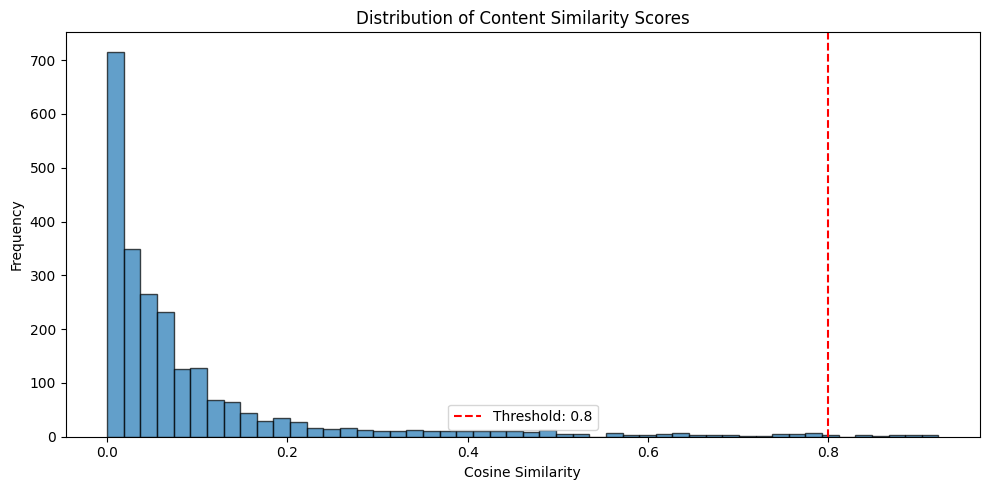

In [8]:
# ============================================================================
# CELL 6: Duplicate Detection
# ============================================================================

print("Computing similarity matrix...")

# Convert embeddings back to numpy array
embeddings_array = np.array([eval(emb) for emb in df_features['embedding']])

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings_array)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

# Find duplicate pairs
duplicate_pairs = []

for i in range(len(similarity_matrix)):
    for j in range(i + 1, len(similarity_matrix)):
        similarity = similarity_matrix[i][j]
        
        if similarity > SIMILARITY_THRESHOLD:
            duplicate_pairs.append({
                'url1': df_features.iloc[i]['url'],
                'url2': df_features.iloc[j]['url'],
                'similarity': round(similarity, 4)
            })

# Create duplicates DataFrame
df_duplicates = pd.DataFrame(duplicate_pairs)

# Thin content detection
df_features['is_thin'] = df_features['word_count'] < THIN_CONTENT_THRESHOLD
thin_content_count = df_features['is_thin'].sum()

# Summary statistics
print(f"\n✓ Duplicate detection complete!")
print(f"\n📊 Summary:")
print(f"Total pages analyzed: {len(df_features)}")
print(f"Duplicate pairs found: {len(df_duplicates)}")
print(f"Thin content pages: {thin_content_count} ({thin_content_count/len(df_features)*100:.1f}%)")

# Save duplicates
if len(df_duplicates) > 0:
    duplicates_path = DATA_DIR / 'duplicates.csv'
    df_duplicates.to_csv(duplicates_path, index=False)
    print(f"✓ Saved duplicates to {duplicates_path}")
    display(df_duplicates)
else:
    print("No duplicate pairs found above threshold.")

# Visualize similarity distribution
plt.figure(figsize=(10, 5))
similarity_values = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
plt.hist(similarity_values, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(SIMILARITY_THRESHOLD, color='red', linestyle='--', label=f'Threshold: {SIMILARITY_THRESHOLD}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Content Similarity Scores')
plt.legend()
plt.tight_layout()
plt.show()

✓ Quality labels created!

📊 Label Distribution:
quality_label
Low       33
Medium    26
High      10
Name: count, dtype: int64

Percentages:
quality_label
Low       47.826087
Medium    37.681159
High      14.492754
Name: proportion, dtype: float64


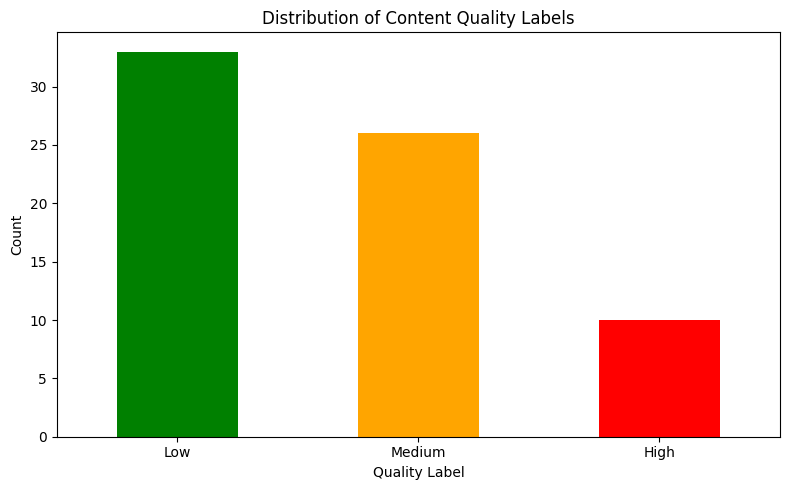

In [9]:
# ============================================================================
# CELL 7: Content Quality Scoring - Label Creation
# ============================================================================

def create_quality_labels(df):
    """
    Create synthetic quality labels based on word count and readability.
    
    Labels:
    - High: word_count > 1500 AND 50 <= readability <= 70
    - Low: word_count < 500 OR readability < 30
    - Medium: all other cases
    """
    conditions = [
        (df['word_count'] > 1500) & (df['flesch_reading_ease'] >= 50) & (df['flesch_reading_ease'] <= 70),
        (df['word_count'] < 500) | (df['flesch_reading_ease'] < 30)
    ]
    
    choices = ['High', 'Low']
    
    df['quality_label'] = np.select(conditions, choices, default='Medium')
    
    return df

# Create labels
df_modeling = df_features.copy()
df_modeling = create_quality_labels(df_modeling)

# Add thin content flag
df_modeling['is_thin'] = df_modeling['word_count'] < THIN_CONTENT_THRESHOLD

print("✓ Quality labels created!")
print(f"\n📊 Label Distribution:")
print(df_modeling['quality_label'].value_counts())
print(f"\nPercentages:")
print(df_modeling['quality_label'].value_counts(normalize=True) * 100)

# Visualize label distribution
plt.figure(figsize=(8, 5))
df_modeling['quality_label'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.xlabel('Quality Label')
plt.ylabel('Count')
plt.title('Distribution of Content Quality Labels')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Features shape: (69, 3)
Target shape: (69,)

Train size: 48
Test size: 21

Training Random Forest Classifier...

✓ Model trained successfully!
Test Accuracy: 0.8571

📊 Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         3
         Low       1.00      1.00      1.00        10
      Medium       0.73      1.00      0.84         8

    accuracy                           0.86        21
   macro avg       0.58      0.67      0.61        21
weighted avg       0.75      0.86      0.80        21



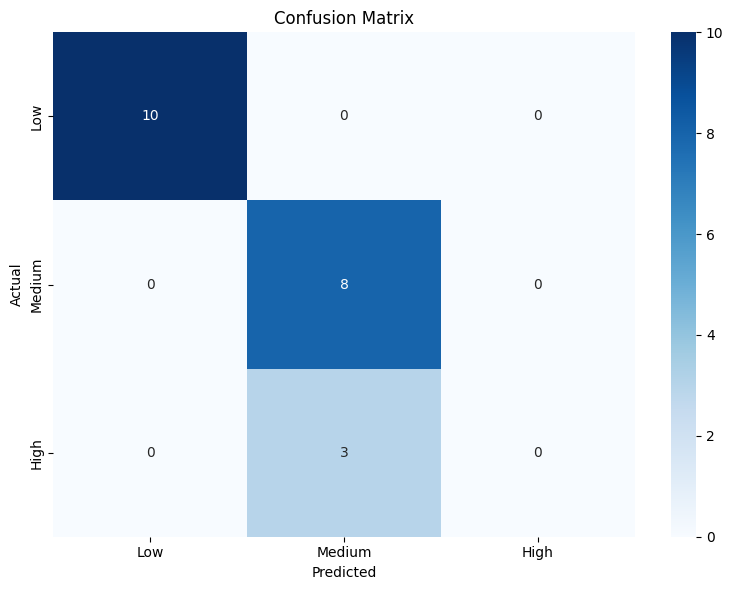


📊 Feature Importance:
               feature  importance
0           word_count    0.350710
1       sentence_count    0.328901
2  flesch_reading_ease    0.320389


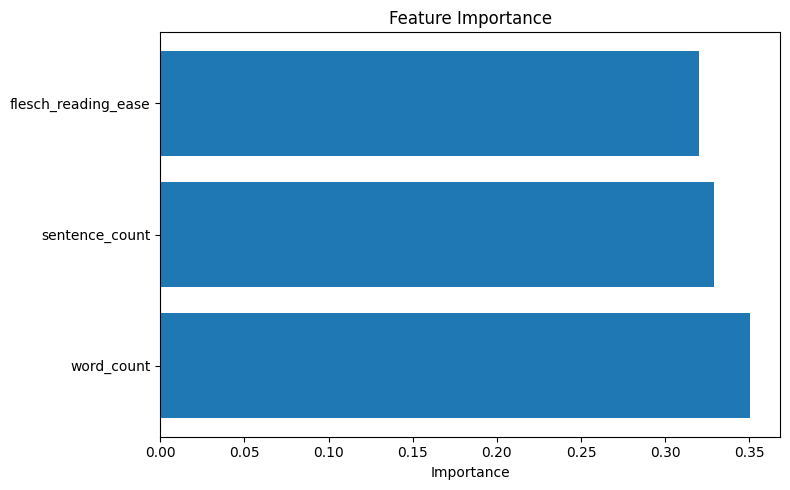

In [ ]:
# ============================================================================
# CELL 8: Train Classification Model (UPDATED)
# ============================================================================

# Prepare features and target - NOW WITH 4 FEATURES INSTEAD OF 3
feature_columns = ['word_count', 'sentence_count', 'flesch_reading_ease', 'avg_word_length']  # ADDED avg_word_length
X = df_modeling[feature_columns].values
y = df_modeling['quality_label'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {feature_columns}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# Train Random Forest model
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✓ Model trained successfully!")
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================================
# CELL 9: Baseline Model Comparison
# ============================================================================

def rule_based_classifier(word_count):
    """Simple rule-based classifier using only word count."""
    if word_count > 1500:
        return 'High'
    elif word_count < 500:
        return 'Low'
    else:
        return 'Medium'

# Baseline predictions
y_baseline = [rule_based_classifier(wc) for wc in X_test[:, 0]]
baseline_accuracy = accuracy_score(y_test, y_baseline)

print(f"Baseline (Rule-based) Accuracy: {baseline_accuracy:.4f}")
print(f"Random Forest Accuracy: {accuracy:.4f}")
print(f"Improvement: {(accuracy - baseline_accuracy):.4f} ({(accuracy - baseline_accuracy)/baseline_accuracy*100:.1f}%)")

Baseline (Rule-based) Accuracy: 0.6190
Random Forest Accuracy: 0.8571
Improvement: 0.2381 (38.5%)


In [12]:
# ============================================================================
# CELL 10: Save Model
# ============================================================================

# Save the trained model
model_path = MODELS_DIR / 'quality_model.pkl'
joblib.dump({
    'model': rf_model,
    'feature_columns': feature_columns,
    'embedding_model_name': 'all-MiniLM-L6-v2'
}, model_path)

print(f"✓ Model saved to {model_path}")

✓ Model saved to ..\models\quality_model.pkl


In [ ]:
# ============================================================================
# CELL 11: Real-Time Analysis Function (UPDATED)
# ============================================================================

# Load the embedding model once
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Load historical embeddings for duplicate detection
historical_embeddings = embeddings_array
historical_urls = df_features['url'].tolist()

def analyze_url(url):
    """
    Analyze a URL for content quality and duplicate detection.
    
    Args:
        url: URL to analyze
        
    Returns:
        dict: Analysis results
    """
    try:
        # Scrape the URL
        print(f"Scraping {url}...")
        html_content = scrape_url(url)
        
        if not html_content:
            return {
                'error': 'Failed to scrape URL',
                'url': url
            }
        
        # Parse HTML
        parsed = parse_html_content(html_content)
        body_text = parsed['body_text']
        
        if not body_text:
            return {
                'error': 'No content extracted',
                'url': url
            }
        
        # Extract features
        clean_text_val = clean_text(body_text)
        word_count = parsed['word_count']
        sentence_count = calculate_sentence_count(body_text)
        readability = calculate_readability(body_text)
        avg_word_len = calculate_avg_word_length(body_text)  # NEW LINE
        
        # Generate embedding
        embedding = embedding_model.encode([clean_text_val])[0]
        
        # Prepare features for model - NOW WITH 4 FEATURES
        features = np.array([[word_count, sentence_count, readability, avg_word_len]])  # ADDED avg_word_len
        
        # Predict quality
        quality_label = rf_model.predict(features)[0]
        quality_proba = rf_model.predict_proba(features)[0]
        
        # Find similar content
        similarities = cosine_similarity([embedding], historical_embeddings)[0]
        similar_indices = np.where(similarities > SIMILARITY_THRESHOLD)[0]
        
        similar_to = []
        for idx in similar_indices:
            similar_to.append({
                'url': historical_urls[idx],
                'similarity': float(round(similarities[idx], 4))
            })
        
        # Sort by similarity
        similar_to = sorted(similar_to, key=lambda x: x['similarity'], reverse=True)
        
        # Prepare result
        result = {
            'url': url,
            'title': parsed['title'],
            'word_count': word_count,
            'sentence_count': sentence_count,
            'readability': round(readability, 2),
            'avg_word_length': round(avg_word_len, 2),  # NEW LINE
            'quality_label': quality_label,
            'quality_confidence': {
                'High': float(round(quality_proba[0], 3)),
                'Low': float(round(quality_proba[1], 3)),
                'Medium': float(round(quality_proba[2], 3))
            },
            'is_thin': word_count < THIN_CONTENT_THRESHOLD,
            'similar_to': similar_to[:5] if similar_to else []
        }
        
        return result
        
    except Exception as e:
        return {
            'error': str(e),
            'url': url
        }

print("✓ Real-time analysis function ready!")
print("\nUsage: result = analyze_url('https://example.com/article')")

✓ Real-time analysis function ready!

Usage: result = analyze_url('https://example.com/article')


In [14]:
# ============================================================================
# CELL 12: Test Real-Time Analysis
# ============================================================================

# Test with a URL from the dataset
test_url = df_extracted.iloc[0]['url']

print(f"Testing with: {test_url}\n")
result = analyze_url(test_url)

print(json.dumps(result, indent=2))


Testing with: https://www.cm-alliance.com/cybersecurity-blog

Scraping https://www.cm-alliance.com/cybersecurity-blog...
{
  "url": "https://www.cm-alliance.com/cybersecurity-blog",
  "title": "Cyber Security Blog",
  "word_count": 4957,
  "sentence_count": 42,
  "readability": 1.74,
  "quality_label": "Low",
  "quality_confidence": {
    "High": 0.04,
    "Low": 0.93,
    "Medium": 0.03
  },
  "is_thin": false,
  "similar_to": []
}


📊 FINAL SUMMARY

1. DATA PROCESSING
   - Total URLs processed: 81
   - Pages with content: 69
   - Average word count: 4286

2. DUPLICATE DETECTION
   - Total pages analyzed: 69
   - Duplicate pairs found: 18
   - Thin content pages: 24 (34.8%)
   - Similarity threshold: 0.8

3. QUALITY MODEL
   - Model: Random Forest Classifier
   - Test Accuracy: 0.8571
   - Baseline Accuracy: 0.6190
   - Improvement: 0.2381

4. LABEL DISTRIBUTION
   - Low: 33 (47.8%)
   - Medium: 26 (37.7%)
   - High: 10 (14.5%)

5. TOP FEATURES
   - word_count: 0.3507
   - sentence_count: 0.3289
   - flesch_reading_ease: 0.3204

6. OUTPUT FILES
   - ..\data\extracted_content.csv
   - ..\data\features.csv
   - ..\data\duplicates.csv
   - ..\models\quality_model.pkl

✓ Pipeline execution complete!


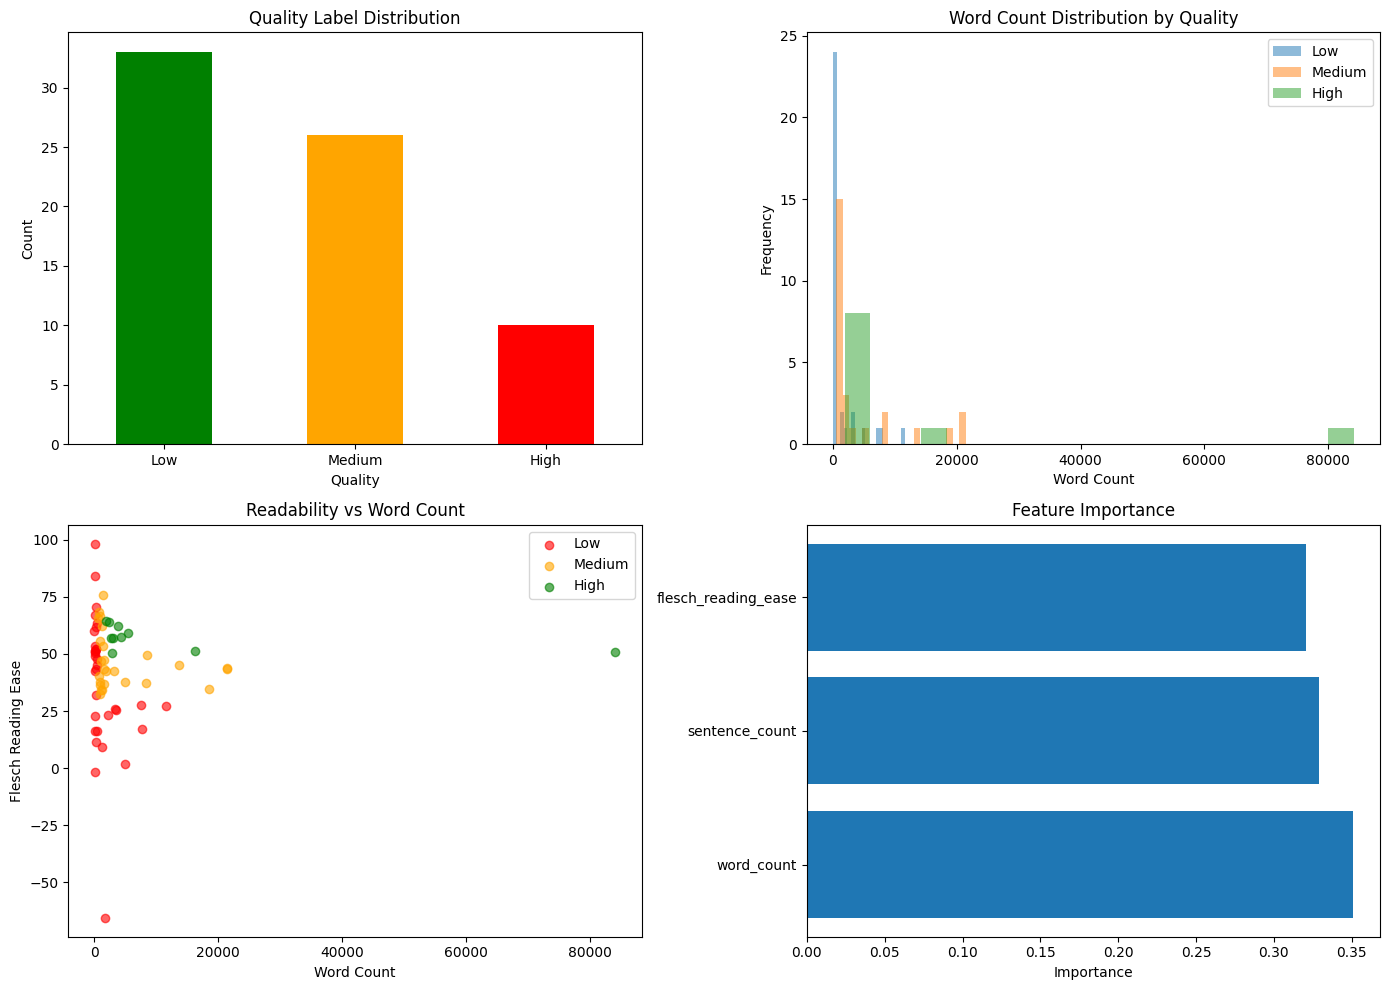


✅ All visualizations generated!


In [15]:
# ============================================================================
# CELL 13: Summary and Visualizations
# ============================================================================

print("="*70)
print("📊 FINAL SUMMARY")
print("="*70)

print(f"\n1. DATA PROCESSING")
print(f"   - Total URLs processed: {len(df_raw)}")
print(f"   - Pages with content: {len(df_extracted)}")
print(f"   - Average word count: {df_extracted['word_count'].mean():.0f}")

print(f"\n2. DUPLICATE DETECTION")
print(f"   - Total pages analyzed: {len(df_features)}")
print(f"   - Duplicate pairs found: {len(df_duplicates)}")
print(f"   - Thin content pages: {thin_content_count} ({thin_content_count/len(df_features)*100:.1f}%)")
print(f"   - Similarity threshold: {SIMILARITY_THRESHOLD}")

print(f"\n3. QUALITY MODEL")
print(f"   - Model: Random Forest Classifier")
print(f"   - Test Accuracy: {accuracy:.4f}")
print(f"   - Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"   - Improvement: {(accuracy - baseline_accuracy):.4f}")

print(f"\n4. LABEL DISTRIBUTION")
label_counts = df_modeling['quality_label'].value_counts()
for label, count in label_counts.items():
    pct = count / len(df_modeling) * 100
    print(f"   - {label}: {count} ({pct:.1f}%)")

print(f"\n5. TOP FEATURES")
for idx, row in feature_importance.iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print(f"\n6. OUTPUT FILES")
print(f"   - {DATA_DIR / 'extracted_content.csv'}")
print(f"   - {DATA_DIR / 'features.csv'}")
print(f"   - {DATA_DIR / 'duplicates.csv'}")
print(f"   - {MODELS_DIR / 'quality_model.pkl'}")

print("\n" + "="*70)
print("✓ Pipeline execution complete!")
print("="*70)

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Quality distribution
ax1 = axes[0, 0]
df_modeling['quality_label'].value_counts().plot(kind='bar', ax=ax1, color=['green', 'orange', 'red'])
ax1.set_title('Quality Label Distribution')
ax1.set_xlabel('Quality')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# 2. Word count distribution by quality
ax2 = axes[0, 1]
for label in ['Low', 'Medium', 'High']:
    data = df_modeling[df_modeling['quality_label'] == label]['word_count']
    ax2.hist(data, alpha=0.5, label=label, bins=20)
ax2.set_title('Word Count Distribution by Quality')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Readability vs Word Count
ax3 = axes[1, 0]
colors = {'Low': 'red', 'Medium': 'orange', 'High': 'green'}
for label in ['Low', 'Medium', 'High']:
    data = df_modeling[df_modeling['quality_label'] == label]
    ax3.scatter(data['word_count'], data['flesch_reading_ease'], 
               alpha=0.6, label=label, color=colors[label])
ax3.set_title('Readability vs Word Count')
ax3.set_xlabel('Word Count')
ax3.set_ylabel('Flesch Reading Ease')
ax3.legend()

# 4. Feature importance
ax4 = axes[1, 1]
ax4.barh(feature_importance['feature'], feature_importance['importance'])
ax4.set_title('Feature Importance')
ax4.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\n✅ All visualizations generated!")